# Data Preprocessing

## Objective

This notebook cleans and prepares the raw Olist Brazilian E-Commerce dataset for downstream analytics and machine learning tasks.

The preprocessing stage focuses on improving data quality by handling missing values, duplicate records, inconsistent data types, and preparing structured datasets for further transformation.

## Tasks

The notebook performs:

- Data validation and quality checks.
- Missing value handling.
- Duplicate record detection and removal.
- Data type correction.
- Initial data transformations.

## Output

The cleaned datasets generated from this notebook will be used as input for the ETL pipeline.

### Data Import

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Standard Library
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

### Data Import

In [2]:
PROJECT_ROOT = Path("../")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
def load_csv(file_path: Path) -> pd.DataFrame:
    """
    Load a CSV file into a pandas DataFrame.

    Parameters
    ----------
    file_path : Path
        Path to CSV file.

    Returns
    -------
    pd.DataFrame
    """

    print(f"\nLoading {file_path.name}...")

    df = pd.read_csv(file_path)

    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    return df

In [4]:
customers = load_csv(
    RAW_DATA_DIR / "olist_customers_dataset.csv"
)

orders = load_csv(
    RAW_DATA_DIR / "olist_orders_dataset.csv"
)

order_items = load_csv(
    RAW_DATA_DIR / "olist_order_items_dataset.csv"
)

payments = load_csv(
    RAW_DATA_DIR / "olist_order_payments_dataset.csv"
)

reviews = load_csv(
    RAW_DATA_DIR / "olist_order_reviews_dataset.csv"
)

products = load_csv(
    RAW_DATA_DIR / "olist_products_dataset.csv"
)

sellers = load_csv(
    RAW_DATA_DIR / "olist_sellers_dataset.csv"
)

geolocation = load_csv(
    RAW_DATA_DIR / "olist_geolocation_dataset.csv"
)

translation = load_csv(
    RAW_DATA_DIR / "product_category_name_translation.csv"
)


Loading olist_customers_dataset.csv...
Rows: 99,441
Columns: 5

Loading olist_orders_dataset.csv...
Rows: 99,441
Columns: 8

Loading olist_order_items_dataset.csv...
Rows: 112,650
Columns: 7

Loading olist_order_payments_dataset.csv...
Rows: 103,886
Columns: 5

Loading olist_order_reviews_dataset.csv...
Rows: 99,224
Columns: 7

Loading olist_products_dataset.csv...
Rows: 32,951
Columns: 9

Loading olist_sellers_dataset.csv...
Rows: 3,095
Columns: 4

Loading olist_geolocation_dataset.csv...
Rows: 1,000,163
Columns: 5

Loading product_category_name_translation.csv...
Rows: 71
Columns: 2


### Convert Date Columns to DateTime

In [5]:
def convert_datetime(df, columns):
    """
    Convert specified columns to datetime.
    Invalid values become NaT.
    """

    for column in columns:

        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

    return df

In [6]:
## Orders Table
order_datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders = convert_datetime(
    orders,
    order_datetime_columns
)


## Reviews Table
review_datetime_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

reviews = convert_datetime(
    reviews,
    review_datetime_columns
)

In [7]:
## Verify datetime conversion
orders.info()
print()
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.0 MB

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------       

### Remove Exact Duplicated Rows

In [8]:
def remove_duplicates(df, name):

    before = len(df)
    df = df.drop_duplicates()
    after = len(df)

    print(name)
    print(f"Rows Before : {before:,}")
    print(f"Rows After  : {after:,}")
    print(f"Removed     : {before-after:,}")

    return df

In [9]:
# Geolocation table has duplicates
geolocation = remove_duplicates(geolocation, "Geolocation")

Geolocation
Rows Before : 1,000,163
Rows After  : 738,332
Removed     : 261,831


### Primary Key Validation

In [10]:
def check_primary_key(df, column, table_name):

    total = len(df)
    unique = df[column].nunique()
    duplicated = total - unique

    print("="*20)
    print(table_name)

    print(f"Primary Key : {column}")
    print(f"Rows         : {total:,}")
    print(f"Unique Keys  : {unique:,}")
    print(f"Duplicates   : {duplicated:,}")

    if duplicated == 0:
        print("PASS: Primary key is unique.")

    else:
        print("WARNING: Duplicate primary keys detected.")

In [11]:
check_primary_key(
    customers,
    "customer_id",
    "Customers"
)

check_primary_key(
    orders,
    "order_id",
    "Orders"
)

check_primary_key(
    products,
    "product_id",
    "Products"
)

check_primary_key(
    sellers,
    "seller_id",
    "Sellers"
)

Customers
Primary Key : customer_id
Rows         : 99,441
Unique Keys  : 99,441
Duplicates   : 0
PASS: Primary key is unique.
Orders
Primary Key : order_id
Rows         : 99,441
Unique Keys  : 99,441
Duplicates   : 0
PASS: Primary key is unique.
Products
Primary Key : product_id
Rows         : 32,951
Unique Keys  : 32,951
Duplicates   : 0
PASS: Primary key is unique.
Sellers
Primary Key : seller_id
Rows         : 3,095
Unique Keys  : 3,095
Duplicates   : 0
PASS: Primary key is unique.


### Foreign Key Validation

In [14]:
# Customers Table
missing_customer = (
    ~orders["customer_id"]
    .isin(customers["customer_id"])
).sum()

print(f"Orders without customer: {missing_customer}")

# Order Items Table
missing_orders = (
    ~order_items["order_id"]
    .isin(orders["order_id"])
).sum()

print(f"Order items without order: {missing_orders}")

# Products Table
missing_products = (
    ~order_items["product_id"]
    .isin(products["product_id"])
).sum()

print(f"Missing products: {missing_products}")

# Sellers Table
missing_sellers = (
    ~order_items["seller_id"]
    .isin(sellers["seller_id"])
).sum()

print(f"Missing sellers: {missing_sellers}")

Orders without customer: 0
Order items without order: 0
Missing products: 0
Missing sellers: 0


### Missing Values Handling

From 01-Data_Understanding, it was found that Orders, Products, and Reviews table contain missing values:

Orders

- Missing delivery timestamps mainly correspond to cancelled or unavailable orders.

Products

- Missing dimensions are limited and unlikely to impact churn prediction.

Reviews

- Missing review comments are expected because customers may submit only a numerical rating.

Conclusion:

No missing values appear to represent systematic data corruption.

#### Reviews table

In [ ]:
# Fill empty comments with (None)
reviews["review_comment_title"] = reviews[
    "review_comment_title"
].fillna("(None)")

reviews["review_comment_message"] = reviews[
    "review_comment_message"
].fillna("(None)")

#### Products

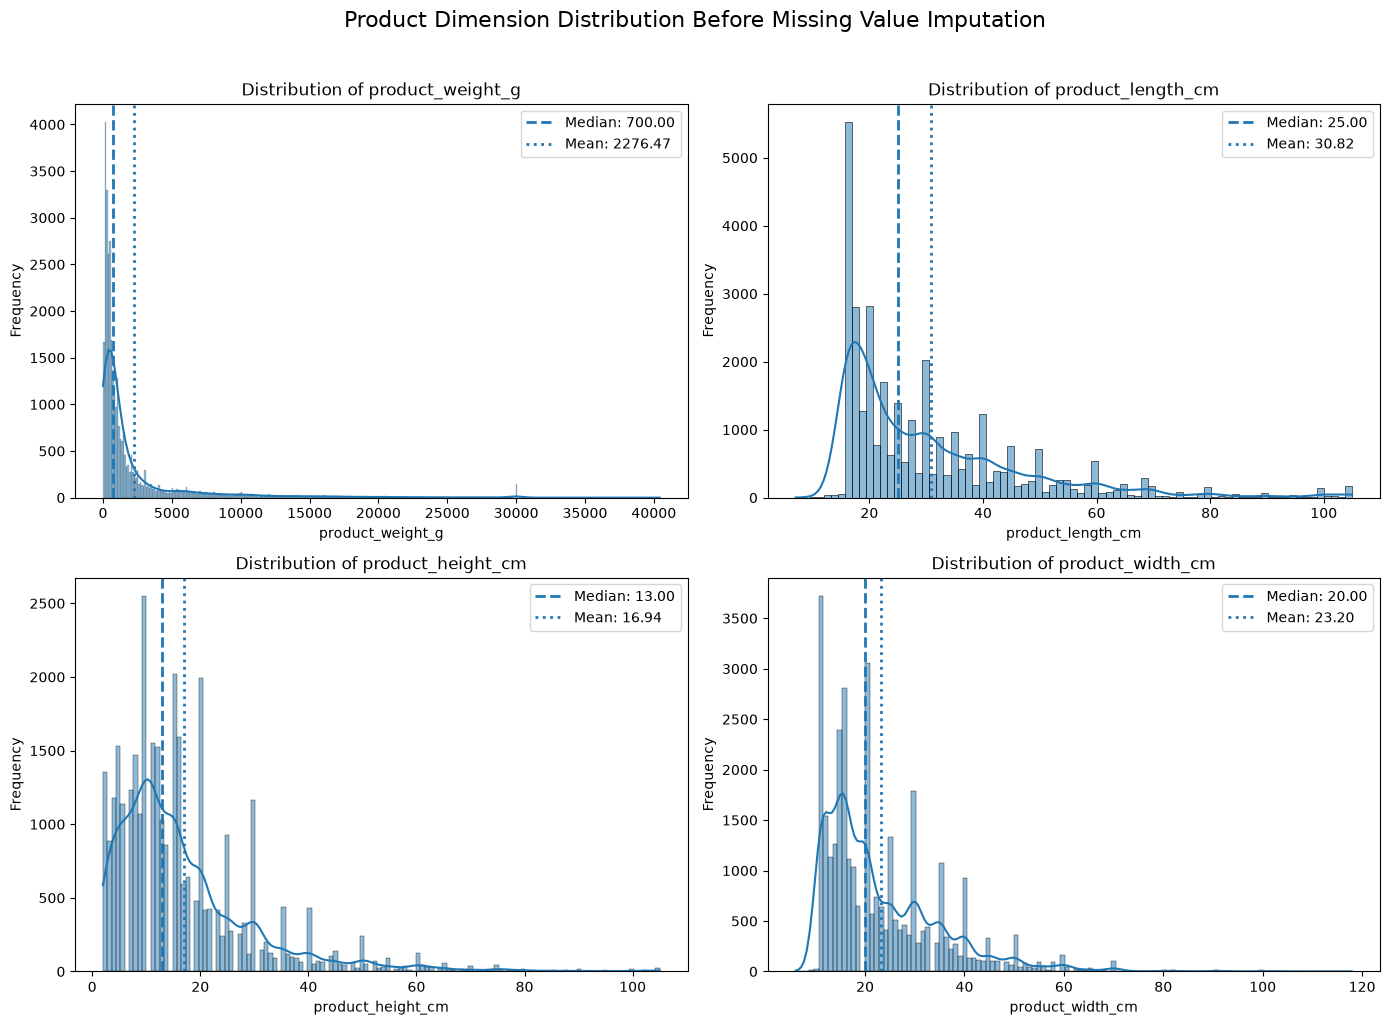

In [18]:
product_numeric_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for i, column in enumerate(product_numeric_columns):

    ax = axes[i]

    # Distribution plot
    sns.histplot(
        data=products,
        x=column,
        kde=True,
        ax=ax
    )

    # Calculate statistics
    median_value = products[column].median()
    mean_value = products[column].mean()

    # Add median line
    ax.axvline(
        median_value,
        linestyle="--",
        linewidth=2,
        label=f"Median: {median_value:.2f}"
    )

    # Add mean line
    ax.axvline(
        mean_value,
        linestyle=":",
        linewidth=2,
        label=f"Mean: {mean_value:.2f}"
    )

    ax.set_title(
        f"Distribution of {column}"
    )

    ax.set_xlabel(column)

    ax.set_ylabel("Frequency")

    ax.legend()


plt.suptitle(
    "Product Dimension Distribution Before Missing Value Imputation",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.show()

All the dimention attributes are heavily right-skewed, so median is more suitable to use for missing value imputation

In [ ]:
# Impute missing values with median
for column in product_numeric_columns:
    median = products[column].median()
    products[column] = products[column].fillna(median)

# Fill missing product category names with "Unknown"
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("(Unknown)")
)

# Fill missing products numeric info with 0
numeric_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

products[numeric_columns] = products[numeric_columns].fillna(0)

### Final Validation

In [22]:
def missing_report(df: pd.DataFrame, name: str):

    missing = df.isna().sum()

    missing = missing[missing > 0]

    print()
    print("=" * 20)
    print(name)

    if missing.empty:

        print("No Missing Values")

    else:

        report = pd.DataFrame({

            "Missing Count": missing,

            "Missing Percentage": (
                missing / len(df) * 100
            ).round(2)

        })

        display(report.sort_values(
            "Missing Percentage",
            ascending=False
        ))

missing_report(orders, "Orders")
missing_report(products, "Products")
missing_report(reviews, "Reviews")


Orders


,Missing Count,Missing Percentage
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



Products
No Missing Values

Reviews
No Missing Values


### Save Cleaned Dataset

In [23]:
customers.to_csv(
    PROCESSED_DATA_DIR / "customers_cleaned.csv",
    index=False
)

orders.to_csv(
    PROCESSED_DATA_DIR / "orders_cleaned.csv",
    index=False
)

order_items.to_csv(
    PROCESSED_DATA_DIR / "order_items_cleaned.csv",
    index=False
)

payments.to_csv(
    PROCESSED_DATA_DIR / "payments_cleaned.csv",
    index=False
)

reviews.to_csv(
    PROCESSED_DATA_DIR / "reviews_cleaned.csv",
    index=False
)

products.to_csv(
    PROCESSED_DATA_DIR / "products_cleaned.csv",
    index=False
)

sellers.to_csv(
    PROCESSED_DATA_DIR / "sellers_cleaned.csv",
    index=False
)

geolocation.to_csv(
    PROCESSED_DATA_DIR / "geolocation_cleaned.csv",
    index=False
)

translation.to_csv(
    PROCESSED_DATA_DIR / "product_category_translation_cleaned.csv",
    index=False
)